In [1]:
import os 
os.chdir('D:\HKUST\\5051_Algoruthm_and_Obejct-Oriented_Programing_for_Modeling\Project\Project1')
import pandas as pd

column_names = [
    'VehicleType',      
    'DirectionTime_O', 
    'GantryID_O',       
    'DirectionTime_D', 
    'GantryID_D',      
    'TripLength',   
    'TripEnd',       
    'TripInformation'  
]

file_path = "TDCS_M06A_20231204_080000.csv"

# original data did not have header, so we set header=None and provide column names
df = pd.read_csv(file_path, header=None, names=column_names) 
print(f"Data shape: {df.shape}")
print(df.columns.tolist())

columns_to_sort = {
    'VehicleType': df['VehicleType'].tolist(),     
    'DirectionTime_O': df['DirectionTime_O'].tolist(),  
    'GantryID_O': df['GantryID_O'].tolist(),       
    'TripLength': df['TripLength'].tolist()
}

for col_name, data in columns_to_sort.items():
    print(f"{col_name} 前十个数据: {data[:10]}")
    print(f"{col_name} 数据类型: {type(data[0])}")

Data shape: (227569, 8)
['VehicleType', 'DirectionTime_O', 'GantryID_O', 'DirectionTime_D', 'GantryID_D', 'TripLength', 'TripEnd', 'TripInformation']
VehicleType 前十个数据: [31, 32, 31, 31, 31, 32, 32, 32, 42, 31]
VehicleType 数据类型: <class 'int'>
DirectionTime_O 前十个数据: ['2023-12-04 08:34:50', '2023-12-04 08:16:35', '2023-12-04 08:20:36', '2023-12-04 08:02:25', '2023-12-04 08:15:54', '2023-12-04 08:24:01', '2023-12-04 08:42:08', '2023-12-04 08:03:05', '2023-12-04 08:18:26', '2023-12-04 08:25:08']
DirectionTime_O 数据类型: <class 'str'>
GantryID_O 前十个数据: ['01F3640S', '01F3185N', '01F0578S', '03F0498N', '01F0467N', '03F3854N', '03F1779S', '03F0961S', '01F3640N', '03F0301S']
GantryID_O 数据类型: <class 'str'>
TripLength 前十个数据: [7.2, 20.03, 13.0, 19.5, 25.9, 34.6, 35.2, 39.9, 5.0, 9.1]
TripLength 数据类型: <class 'float'>


In [2]:
from datetime import datetime
import re

def preprocess_data_for_sorting(col_name, data):
    """
    根据列名对数据进行预处理，使其适合排序
    返回：处理后的数据列表
    """
    if col_name == "VehicleType":
        # int
        return data  # 保持原样，由排序算法处理

    elif col_name == "DirectionTime_O":
        # str transferm to timestamp
        def to_timestamp(time_str):
            dt = datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S')
            return int(dt.timestamp())
        return [to_timestamp(x) for x in data]

    elif col_name == "GantryID_O":
        # str
        # def natural_sort_key(s):
        #     # 我们只取数字部分转成 int，其他保持字符串
        #     return [int(text) if text.isdigit() else text.lower() 
        #             for text in re.split('([0-9]+)', s)]
        # return [natural_sort_key(x) for x in data]
        # 即使你用 natural_sort_key，数据中有很多前缀相同的 ID（比如大量 01F...），
        # Quick Sort 的分区可能仍然不均衡，导致递归深度过大
        return data
    elif col_name == "TripLength":
        # float 
        return data

    else:
        return data

In [3]:
# get random subset

import random
def get_subsets(data, sizes=[0.2, 0.25, 1/3, 0.5, 1], seed=42):
    """
    resampling original data, get different size subset
    """
    random.seed(seed)  
    subsets = {}
    for size_ratio in sizes:
        n = int(len(data) * size_ratio)
        subsets[size_ratio] = random.sample(data, n)
    return subsets

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def plot_performance(results, algorithm_name):
    """
    plot the run time in log-log scale and check if the time complexity is the same as expected
    :param results: the dictionary storing the time results
    :param algorithm_name: the name of the sorting algorithm
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 
    axes = axes.flatten() 

    for i, (col_name, time_dict) in enumerate(results.items()):
        ax = axes[i]
        
        # prepare data for plotting
        sizes = list(time_dict.keys())  # [0.2, 0.25, 1/3, 0.5, 1]
        times = list(time_dict.values())  # times
        
        # calculate actual data sizes
        n_full = len(columns_to_sort[col_name])
        n_values = [int(n_full * size) for size in sizes]  # actual data sizes
        
        # use log-log scale to plot
        ax.loglog(n_values, times, 'o-', label='actual time', markersize=8)
        
        if len(n_values) > 0:
            base_n = n_values[0]
            base_t = times[0]
            # O(n) line
            o_n = [base_t * (n / base_n) for n in n_values]
            # O(n^2) line
            o_n2 = [base_t * ((n / base_n) ** 2) for n in n_values]
            
            ax.loglog(n_values, o_n, '--', color='red', label='O(n)')
            ax.loglog(n_values, o_n2, '--', color='green', label='O(n^2)')
        
        ax.set_title(f"{col_name}")
        ax.set_xlabel("data size (n)")
        ax.set_ylabel("time (seconds)")
        ax.grid(True, which="both", ls="--")
        ax.legend()
    
    plt.suptitle(f"{algorithm_name} ", fontsize=16)
    plt.tight_layout()
    plt.show()

Running Qucik Sort performance
[31, 32, 31]
  VehicleType [size_ratio:0.20]: 0.0081 seconds
  VehicleType [size_ratio:0.25]: 0.0093 seconds
  VehicleType [size_ratio:0.33]: 0.0149 seconds
  VehicleType [size_ratio:0.50]: 0.0182 seconds
  VehicleType [size_ratio:1.00]: 0.0325 seconds
[1701650090, 1701648995, 1701649236]
  DirectionTime_O [size_ratio:0.20]: 0.0811 seconds
  DirectionTime_O [size_ratio:0.25]: 0.1033 seconds
  DirectionTime_O [size_ratio:0.33]: 0.1387 seconds
  DirectionTime_O [size_ratio:0.50]: 0.2002 seconds
  DirectionTime_O [size_ratio:1.00]: 0.4170 seconds
['01F3640S', '01F3185N', '01F0578S']
  GantryID_O [size_ratio:0.20]: 0.0448 seconds
  GantryID_O [size_ratio:0.25]: 0.0529 seconds
  GantryID_O [size_ratio:0.33]: 0.0804 seconds
  GantryID_O [size_ratio:0.50]: 0.1333 seconds
  GantryID_O [size_ratio:1.00]: 0.2479 seconds
[7.2, 20.03, 13.0]
  TripLength [size_ratio:0.20]: 0.0485 seconds
  TripLength [size_ratio:0.25]: 0.0725 seconds
  TripLength [size_ratio:0.33]: 0.

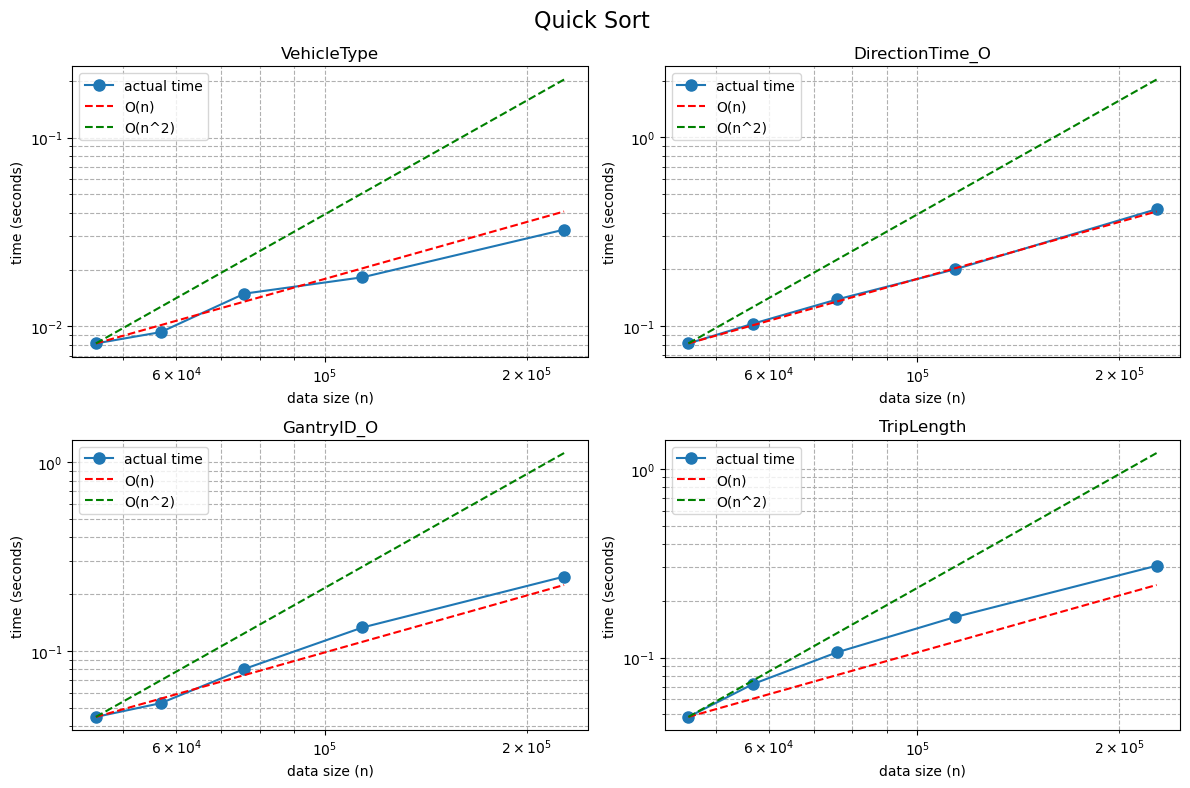

In [147]:
# Quick Sort
# stack overflow remember to mention in report

# time sorting algorithms
import time

def time_sort_algorithm(sort_func, data, num_runs=1):
    """
    Calculate the time for different sort algorithms
    """
    total_time = 0
    for _ in range(num_runs):
        data_copy = data.copy()  
        start = time.time()
        sort_func(data_copy)
        end = time.time()
        total_time += end - start
    return total_time / num_runs 


def quicksort(arr, low=0, high=None):
    if high is None:
        high = len(arr) - 1
    if low >= high:
        return

    lt = low
    i = low
    gt = high
    pivot = arr[low]

    while i <= gt:
        if arr[i] < pivot:
            arr[lt], arr[i] = arr[i], arr[lt]
            lt += 1
            i += 1
        elif arr[i] > pivot:
            arr[i], arr[gt] = arr[gt], arr[i]
            gt -= 1
        else:
            i += 1

    quicksort(arr, low, lt - 1)
    quicksort(arr, gt + 1, high)

def partition(arr, low, high):
    pivot = arr[high] 
    i = low - 1      
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

print("Running Qucik Sort performance")
results_quick = {}
for col_name , original_data in columns_to_sort.items():
    processed_data = preprocess_data_for_sorting(col_name, original_data)
    print(processed_data[:3])
    subsets = get_subsets(processed_data)   
    results_quick[col_name] = {}
    for size_ratio, subset in subsets.items():
        t = time_sort_algorithm(quicksort, subset)
        results_quick[col_name][size_ratio] = t
        print(f"  {col_name} [size_ratio:{size_ratio:>4.2f}]: {t:.4f} seconds")

# plot
plot_performance(results_quick, "Quick Sort")


Running Merge Sort performance
  VehicleType [size_ratio:0.20]: 0.1312 seconds
  VehicleType [size_ratio:0.25]: 0.1472 seconds
  VehicleType [size_ratio:0.33]: 0.2330 seconds
  VehicleType [size_ratio:0.50]: 0.3368 seconds
  VehicleType [size_ratio:1.00]: 0.7123 seconds
  DirectionTime_O [size_ratio:0.20]: 0.1451 seconds
  DirectionTime_O [size_ratio:0.25]: 0.1780 seconds
  DirectionTime_O [size_ratio:0.33]: 0.2650 seconds
  DirectionTime_O [size_ratio:0.50]: 0.3829 seconds
  DirectionTime_O [size_ratio:1.00]: 0.8189 seconds
  GantryID_O [size_ratio:0.20]: 0.1338 seconds
  GantryID_O [size_ratio:0.25]: 0.1712 seconds
  GantryID_O [size_ratio:0.33]: 0.2338 seconds
  GantryID_O [size_ratio:0.50]: 0.3630 seconds
  GantryID_O [size_ratio:1.00]: 0.7637 seconds
  TripLength [size_ratio:0.20]: 0.1310 seconds
  TripLength [size_ratio:0.25]: 0.1825 seconds
  TripLength [size_ratio:0.33]: 0.2410 seconds
  TripLength [size_ratio:0.50]: 0.3593 seconds
  TripLength [size_ratio:1.00]: 0.7794 seconds

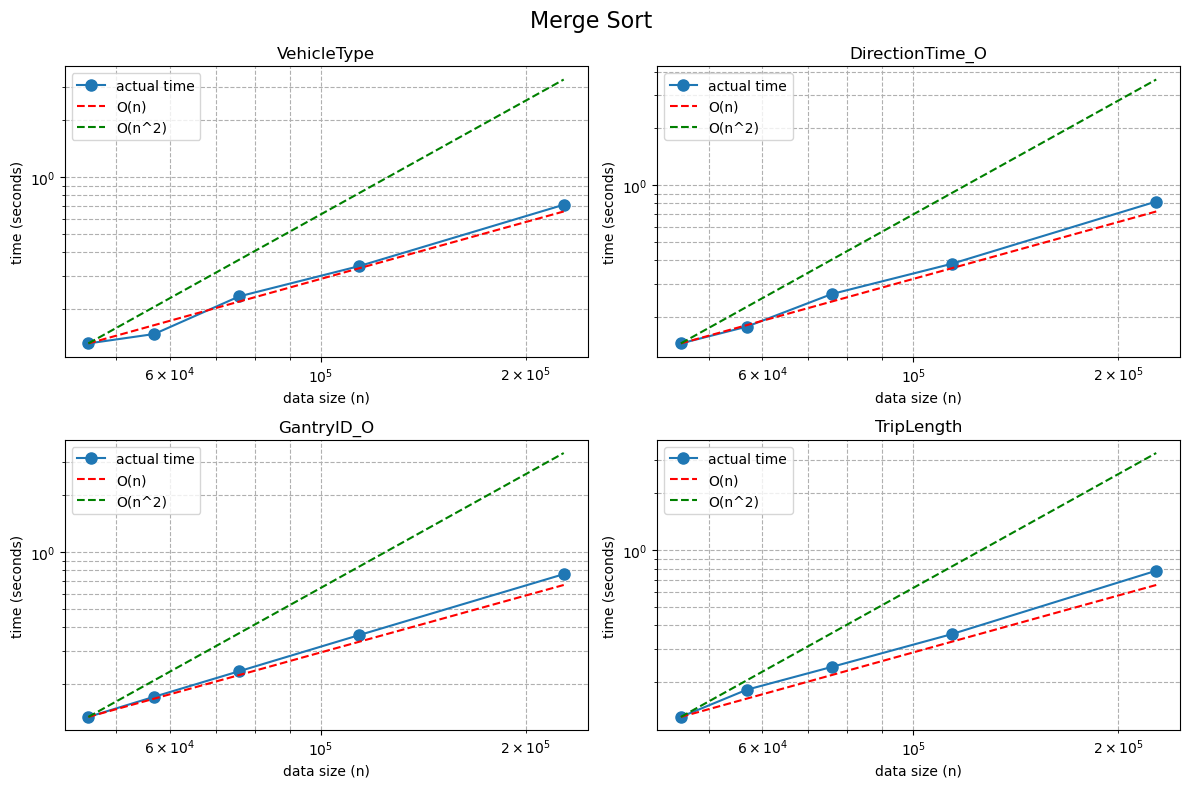

In [110]:
# Merge Sort

def time_sort_algorithm(sort_func, data, is_inplace=True):
    import time
    start = time.time()
    if is_inplace:
        data_copy = data.copy()
        sort_func(data_copy)
    else:
        # Merge Sort 返回新数组
        data_copy = sort_func(data)
    end = time.time()
    return end - start

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

print("Running Merge Sort performance")
results_merge = {}
for col_name , original_data in columns_to_sort.items():
    processed_data = preprocess_data_for_sorting(col_name, original_data)
    subsets = get_subsets(processed_data)   
    results_merge[col_name] = {}
    for size_ratio, subset in subsets.items():
        t = time_sort_algorithm(merge_sort, subset, is_inplace=False)
        results_merge[col_name][size_ratio] = t
        print(f"  {col_name} [size_ratio:{size_ratio:>4.2f}]: {t:.4f} seconds")

# plot
plot_performance(results_merge, "Merge Sort")

Running Heap Sort performance
  VehicleType [size_ratio:0.20]: 0.0850 seconds
  VehicleType [size_ratio:0.25]: 0.1130 seconds
  VehicleType [size_ratio:0.33]: 0.1565 seconds
  VehicleType [size_ratio:0.50]: 0.2401 seconds
  VehicleType [size_ratio:1.00]: 0.5154 seconds
  DirectionTime_O [size_ratio:0.20]: 0.2179 seconds
  DirectionTime_O [size_ratio:0.25]: 0.2948 seconds
  DirectionTime_O [size_ratio:0.33]: 0.3800 seconds
  DirectionTime_O [size_ratio:0.50]: 0.5986 seconds
  DirectionTime_O [size_ratio:1.00]: 1.2948 seconds
  GantryID_O [size_ratio:0.20]: 0.2025 seconds
  GantryID_O [size_ratio:0.25]: 0.2640 seconds
  GantryID_O [size_ratio:0.33]: 0.3530 seconds
  GantryID_O [size_ratio:0.50]: 0.5670 seconds
  GantryID_O [size_ratio:1.00]: 1.2129 seconds
  TripLength [size_ratio:0.20]: 0.2291 seconds
  TripLength [size_ratio:0.25]: 0.2874 seconds
  TripLength [size_ratio:0.33]: 0.4008 seconds
  TripLength [size_ratio:0.50]: 0.5682 seconds
  TripLength [size_ratio:1.00]: 1.2520 seconds


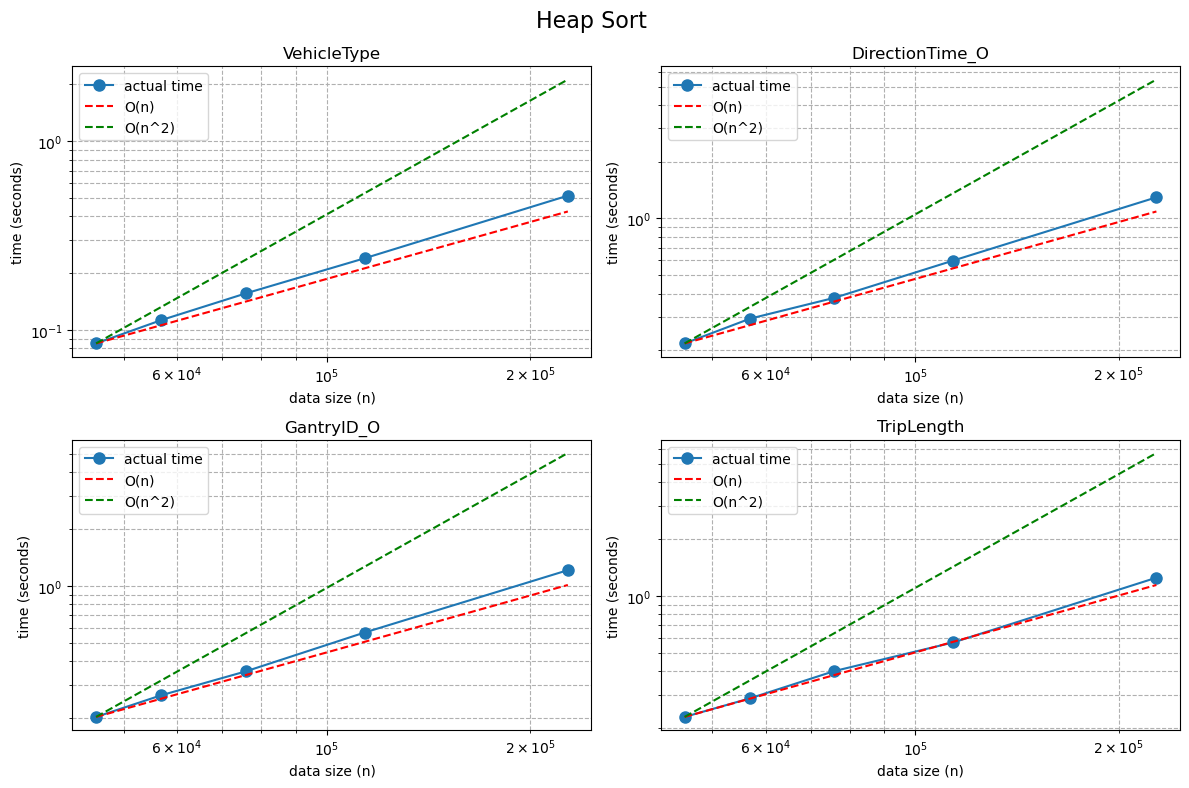

In [111]:
# Heap Sort

def time_sort_algorithm(sort_func, data, num_runs=1):
    """
    Calculate the time for different sort algorithms
    """
    total_time = 0
    for _ in range(num_runs):
        data_copy = data.copy()  
        start = time.time()
        sort_func(data_copy)
        end = time.time()
        total_time += end - start
    return total_time / num_runs 

def heap_sort(arr):
    n = len(arr)
    # max heapify
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)

    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0] 
        heapify(arr, i, 0)             

def heapify(arr, n, i):
    """
    adjust the subtree rooted at index i to be a max heap
    arr: array
    n: size of the heap
    i: current root index
    """
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left
    if right < n and arr[right] > arr[largest]:
        largest = right

    # if largest is not root, swap and continue heapifying
    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

print("Running Heap Sort performance")
results_heap = {}
for col_name , original_data in columns_to_sort.items():
    processed_data = preprocess_data_for_sorting(col_name, original_data)
    subsets = get_subsets(processed_data)   
    results_heap[col_name] = {}
    for size_ratio, subset in subsets.items():
        t = time_sort_algorithm(heap_sort, subset)
        results_heap[col_name][size_ratio] = t
        print(f"  {col_name} [size_ratio:{size_ratio:>4.2f}]: {t:.4f} seconds")

# plot
plot_performance
plot_performance(results_heap, "Heap Sort")

Running Insertion Sort performance
[31, 32, 31]
  VehicleType [size_ratio:0.20]: 71.8228 seconds
  VehicleType [size_ratio:0.25]: 179.8527 seconds
  VehicleType [size_ratio:0.33]: 320.8524 seconds
  VehicleType [size_ratio:0.50]: 683.1462 seconds
  VehicleType [size_ratio:1.00]: 1964.0002 seconds
[1701650090, 1701648995, 1701649236]
  DirectionTime_O [size_ratio:0.20]: 213.8827 seconds
  DirectionTime_O [size_ratio:0.25]: 343.9847 seconds
  DirectionTime_O [size_ratio:0.33]: 658.7038 seconds
  DirectionTime_O [size_ratio:0.50]: 977.1971 seconds
  DirectionTime_O [size_ratio:1.00]: 9363.3865 seconds
['01F3640S', '01F3185N', '01F0578S']
  GantryID_O [size_ratio:0.20]: 207.4313 seconds
  GantryID_O [size_ratio:0.25]: 354.3939 seconds
  GantryID_O [size_ratio:0.33]: 587.6132 seconds
  GantryID_O [size_ratio:0.50]: 910.2113 seconds
  GantryID_O [size_ratio:1.00]: 2733.6181 seconds
[7.2, 20.03, 13.0]
  TripLength [size_ratio:0.20]: 45.6648 seconds
  TripLength [size_ratio:0.25]: 72.4732 seco

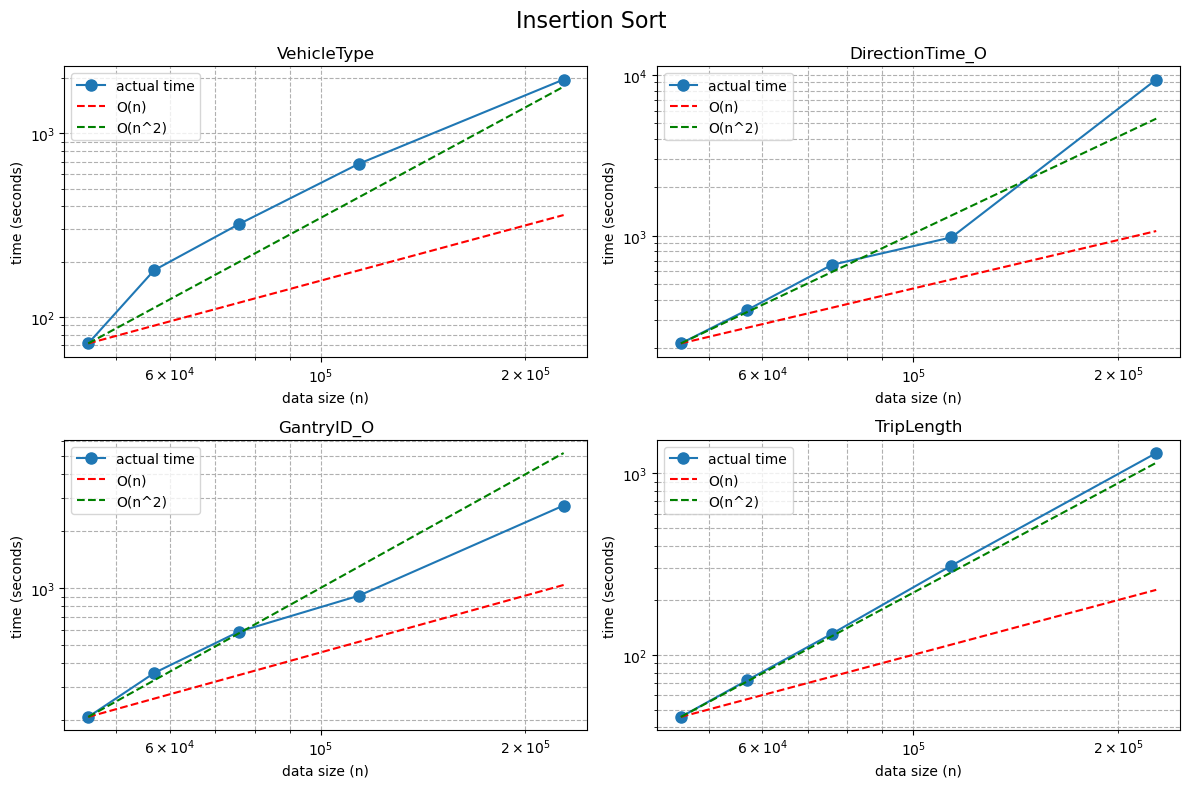

In [8]:
# Insertion Sort
def insertion_sort(arr):
    n = len(arr)
    for i in range(1, n):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

print("Running Insertion Sort performance")
results_insertion = {}
for col_name , original_data in columns_to_sort.items():
    processed_data = preprocess_data_for_sorting(col_name, original_data)
    print(processed_data[:3])
    subsets = get_subsets(processed_data)   
    results_insertion[col_name] = {}
    for size_ratio, subset in subsets.items():
        t = time_sort_algorithm(insertion_sort, subset)
        results_insertion[col_name][size_ratio] = t
        print(f"  {col_name} [size_ratio:{size_ratio:>4.2f}]: {t:.4f} seconds")

# plot
plot_performance(results_insertion, "Insertion Sort")

Running Counting Sort performance
  VehicleType [size_ratio:0.20]: 0.0078 seconds
  VehicleType [size_ratio:0.25]: 0.0111 seconds
  VehicleType [size_ratio:0.33]: 0.0109 seconds
  VehicleType [size_ratio:0.50]: 0.0181 seconds
  VehicleType [size_ratio:1.00]: 0.0407 seconds
  DirectionTime_O [size_ratio:0.20]: 0.0096 seconds
  DirectionTime_O [size_ratio:0.25]: 0.0078 seconds
  DirectionTime_O [size_ratio:0.33]: 0.0153 seconds
  DirectionTime_O [size_ratio:0.50]: 0.0186 seconds
  DirectionTime_O [size_ratio:1.00]: 0.0305 seconds
  Skipping GantryID_O - Counting Sort only works on integers
  Skipping TripLength - Counting Sort only works on integers


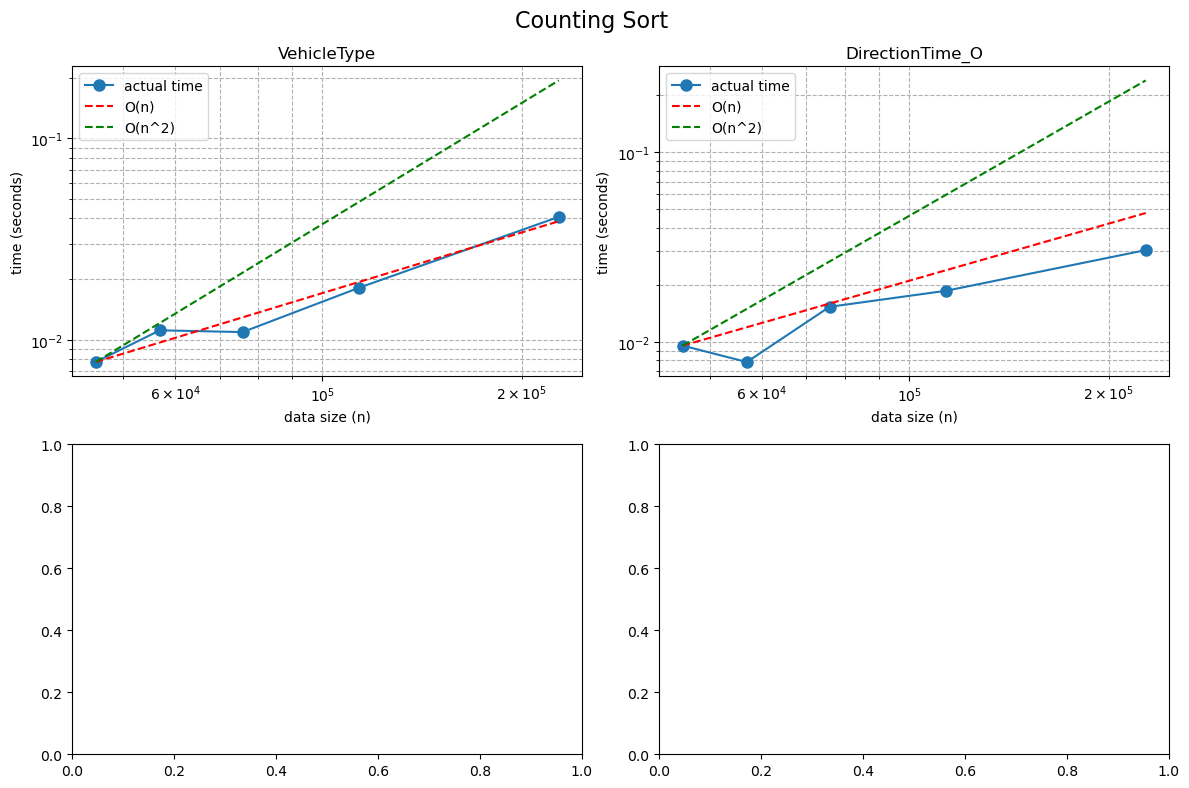

In [139]:
# Counting Sort
# Especially useful for sorting integers within a known, limited range.

def counting_sort(arr):
    if not arr:
        return arr
    
    min_val, max_val = min(arr), max(arr)
    range_of_elements = max_val - min_val + 1
    
    count = [0] * range_of_elements
    for num in arr:
        count[num - min_val] += 1
    
    idx = 0
    for i in range(range_of_elements):
        while count[i] > 0:
            arr[idx] = i + min_val
            idx += 1
            count[i] -= 1

print(f"Running Counting Sort performance")
results_counting = {}
for col_name , original_data in columns_to_sort.items():
    if col_name == "GantryID_O" or col_name == "TripLength" :
        print(f"  Skipping {col_name} - Counting Sort only works on integers")
        continue
    processed_data = preprocess_data_for_sorting(col_name, original_data)
    subsets = get_subsets(processed_data)   
    results_counting[col_name] = {}
    for size_ratio, subset in subsets.items():
        t = time_sort_algorithm(counting_sort, subset)
        results_counting[col_name][size_ratio] = t
        print(f"  {col_name} [size_ratio:{size_ratio:>4.2f}]: {t:.4f} seconds")

# plot
plot_performance(results_counting, "Counting Sort")